In [ ]:
!nvidia-smi

Tue May  5 08:42:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%%bash
set -e

if [ ! -d /usr/local/miniconda ]; then
  wget -q https://repo.anaconda.com/miniconda/Miniconda3-py38_23.3.1-0-Linux-x86_64.sh -O /tmp/miniconda.sh
  bash /tmp/miniconda.sh -b -p /usr/local/miniconda
fi

source /usr/local/miniconda/etc/profile.d/conda.sh
conda --version

PREFIX=/usr/local/miniconda
Unpacking payload ...

Installing base environment...





Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local/miniconda
conda 23.3.1


In [ ]:
%%bash
set -e

source /usr/local/miniconda/etc/profile.d/conda.sh

# 기존 ovseg 환경이 꼬였을 수 있으니 삭제 후 재생성 권장
conda env remove -n ovseg -y || true
conda create -n ovseg python=3.8 -y

conda activate ovseg

python -m pip install --upgrade pip
python -m pip install "setuptools==59.5.0" wheel

# PyTorch는 conda 말고 pip wheel로 설치
python -m pip install \
  torch==1.10.1+cu113 \
  torchvision==0.11.2+cu113 \
  torchaudio==0.10.1+cu113 \
  -f https://download.pytorch.org/whl/cu113/torch_stable.html

# OVSeg / Detectron2 주변 의존성
python -m pip install \
  "numpy==1.23.5" \
  "cython==0.29.36" \
  "scipy==1.10.1" \
  "shapely==1.8.5.post1" \
  "timm==0.6.13" \
  "h5py==3.8.0" \
  "wandb==0.15.12" \
  "fire==0.5.0" \
  "opencv-python==4.7.0.72" \
  "pandas==1.5.3" \
  "braceexpand==0.1.7" \
  "torch-ema==0.3" \
  "torchmetrics==0.11.4" \
  "webdataset==0.2.48" \
  "gdown==4.7.1" \
  "ftfy==6.1.1" \
  "regex" \
  "tqdm" \
  "matplotlib" \
  "Pillow"

# Detectron2는 torch1.10/cu113용 wheel 사용
python -m pip install detectron2 \
  -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu113/torch1.10/index.html

python - <<'PY'
import torch, torchvision
import detectron2

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())
print("detectron2 imported successfully")
PY

Solving environment: ...working... failed with repodata from current_repodata.json, will retry with next repodata source.
Solving environment: ...working... done

## Package Plan ##

  environment location: /usr/local/miniconda/envs/ovseg

  added / updated specs:
    - python=3.8


The following NEW packages will be INSTALLED:

  _libgcc_mutex      pkgs/main/linux-64::_libgcc_mutex-0.1-main 
  _openmp_mutex      pkgs/main/linux-64::_openmp_mutex-5.1-1_gnu 
  ca-certificates    pkgs/main/linux-64::ca-certificates-2026.3.19-h06a4308_0 
  ld_impl_linux-64   pkgs/main/linux-64::ld_impl_linux-64-2.44-h9e0c5a2_3 
  libffi             pkgs/main/linux-64::libffi-3.4.8-hc5d346e_2 
  libgcc             pkgs/main/linux-64::libgcc-15.2.0-h69a1729_7 
  libgcc-ng          pkgs/main/linux-64::libgcc-ng-15.2.0-h166f726_7 
  libgomp            pkgs/main/linux-64::libgomp-15.2.0-h4751f2c_7 
  libstdcxx          pkgs/main/linux-64::libstdcxx-15.2.0-h39759b7_7 
  libstdcxx-ng       pkgs/main/linux-64::li


Remove all packages in environment /usr/local/miniconda/envs/ovseg:



==> WARNING: A newer version of conda exists. <==
  current version: 23.3.1
  latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=26.3.2




In [ ]:
%%bash
set -e

source /usr/local/miniconda/etc/profile.d/conda.sh
conda activate ovseg

cd /content

if [ ! -d ov-seg ]; then
  git clone https://github.com/facebookresearch/ov-seg.git
fi

cd /content/ov-seg

cd third_party/CLIP
python -m pip install -Ue .

cd /content/ov-seg

# numpy np.int 호환 패치
python - <<'PY'
from pathlib import Path

p = Path("open_vocab_seg/utils/predictor.py")
if p.exists():
    s = p.read_text()
    s = s.replace("np.int)", "np.int64)")
    s = s.replace("dtype=np.int", "dtype=np.int64")
    p.write_text(s)
    print("patched:", p)
else:
    print("predictor.py not found")
PY

Obtaining file:///content/ov-seg/third_party/CLIP
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py develop for clip
patched: open_vocab_seg/utils/predictor.py


Cloning into 'ov-seg'...
  DEPRECATION: Legacy editable install of clip==1.0 from file:///content/ov-seg/third_party/CLIP (setup.py develop) is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457


In [ ]:
%%bash
set -e

source /usr/local/miniconda/etc/profile.d/conda.sh
conda activate ovseg

cd /content/ov-seg
mkdir -p checkpoints

python - <<'PY'
from huggingface_hub import hf_hub_download
from pathlib import Path
import shutil

target = Path("checkpoints/ovseg_swinbase_vitL14_ft_mpt.pth")

if not target.exists():
    ckpt_path = hf_hub_download(
        repo_id="facebook/ov-seg",
        filename="ovseg_swinbase_vitL14_ft_mpt.pth",
        repo_type="space"
    )
    shutil.copy(ckpt_path, target)

print("checkpoint saved to:", target)
print("size MB:", target.stat().st_size / 1024 / 1024)
PY

ls -lh checkpoints/

checkpoint saved to: checkpoints/ovseg_swinbase_vitL14_ft_mpt.pth
size MB: 2030.7003297805786
total 2.0G
-rw-r--r-- 1 root root 2.0G May  5 08:59 ovseg_swinbase_vitL14_ft_mpt.pth


In [ ]:
%%bash
set -e

source /usr/local/miniconda/etc/profile.d/conda.sh
conda activate ovseg

python -m pip install --force-reinstall "Pillow==9.5.0"

python - <<'PY'
from PIL import Image
import PIL

print("Pillow:", PIL.__version__)
print("Has Image.LINEAR:", hasattr(Image, "LINEAR"))
print("Has Image.BILINEAR:", hasattr(Image, "BILINEAR"))
PY

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 116.5 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 10.4.0
    Uninstalling pillow-10.4.0:
      Successfully uninstalled pillow-10.4.0
Pillow: 9.5.0
Has Image.LINEAR: True
Has Image.BILINEAR: True


<stdin>:5: DeprecationWarning: LINEAR is deprecated and will be removed in Pillow 10 (2023-07-01). Use BILINEAR or Resampling.BILINEAR instead.


In [ ]:
%%bash
set -e

source /usr/local/miniconda/etc/profile.d/conda.sh
conda activate ovseg

cd /content/ov-seg

python - <<'PY'
from pathlib import Path

p = Path("open_vocab_seg/utils/predictor.py")
s = p.read_text()

# 잘못 중복 패치된 부분 복구
s = s.replace("np.int6464", "np.int64")

# 혹시 남아 있는 deprecated np.int도 안전하게 처리
s = s.replace("dtype=np.int)", "dtype=np.int64)")
s = s.replace("dtype=np.int,", "dtype=np.int64,")
s = s.replace("dtype=np.int\n", "dtype=np.int64\n")

p.write_text(s)

print("patched:", p)

# 확인 출력
for i, line in enumerate(p.read_text().splitlines(), start=1):
    if "np.int" in line:
        print(f"{i}: {line}")
PY

patched: open_vocab_seg/utils/predictor.py
124:             pred_mask = np.array(pred_mask, dtype=np.int64)


In [ ]:
%%bash
set -e

source /usr/local/miniconda/etc/profile.d/conda.sh
conda activate ovseg

cd /content/ov-seg
mkdir -p pred

python demo.py \
  --config-file configs/ovseg_swinB_vitL_demo.yaml \
  --class-names 'Oculus' 'Ukulele' \
  --input ./resources/demo_samples/sample_03.jpeg \
  --output ./pred \
  --opts MODEL.WEIGHTS ./checkpoints/ovseg_swinbase_vitL14_ft_mpt.pth

[05/05 09:03:01 detectron2]: Arguments: Namespace(class_names=['Oculus', 'Ukulele'], config_file='configs/ovseg_swinB_vitL_demo.yaml', input=['./resources/demo_samples/sample_03.jpeg'], opts=['MODEL.WEIGHTS', './checkpoints/ovseg_swinbase_vitL14_ft_mpt.pth'], output='./pred')
WARNING [05/05 09:03:01 fvcore.common.config]: Loading config configs/ovseg_swinB_vitL_demo.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.
[05/05 09:03:18 fvcore.common.checkpoint]: [Checkpointer] Loading from ./checkpoints/ovseg_swinbase_vitL14_ft_mpt.pth ...
[05/05 09:03:34 detectron2]: ./resources/demo_samples/sample_03.jpeg: finished in 6.73s


/content/ov-seg/third_party/CLIP/clip/clip.py:25: UserWarning: PyTorch version 1.7.1 or higher is recommended
  warnings.warn("PyTorch version 1.7.1 or higher is recommended")
/usr/local/miniconda/envs/ovseg/lib/python3.8/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/miniconda/envs/ovseg/lib/python3.8/site-packages/detectron2/structures/image_list.py:88: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, ro

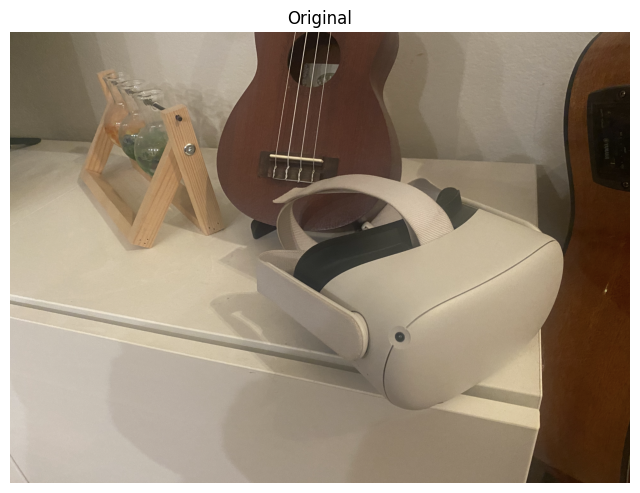

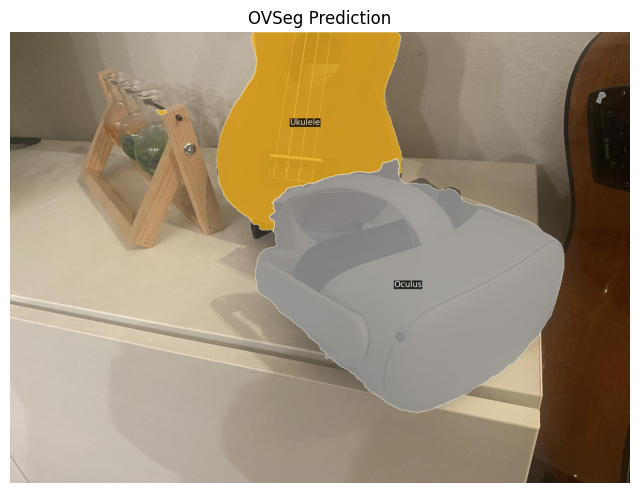

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

orig_path = Path("/content/ov-seg/resources/demo_samples/sample_03.jpeg")
pred_path = Path("/content/ov-seg/pred/sample_03.jpeg")

orig = Image.open(orig_path).convert("RGB")
pred = Image.open(pred_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(orig)
plt.axis("off")
plt.title("Original")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(pred)
plt.axis("off")
plt.title("OVSeg Prediction")
plt.show()